In [1]:
#imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error , mean_absolute_error
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import cross_val_score

In [2]:
df=pd.read_csv("cars_clus.csv")
print(df.index)
print("All columns are")
ai=0
for i in df:
    print(ai,i)
    ai+=1

RangeIndex(start=0, stop=117, step=1)
All columns are
0 manufact
1 model
2 sales
3 resale
4 type
5 price
6 engine_s
7 horsepow
8 wheelbas
9 width
10 length
11 curb_wgt
12 fuel_cap
13 mpg
14 lnsales
15 partition


<Axes: >

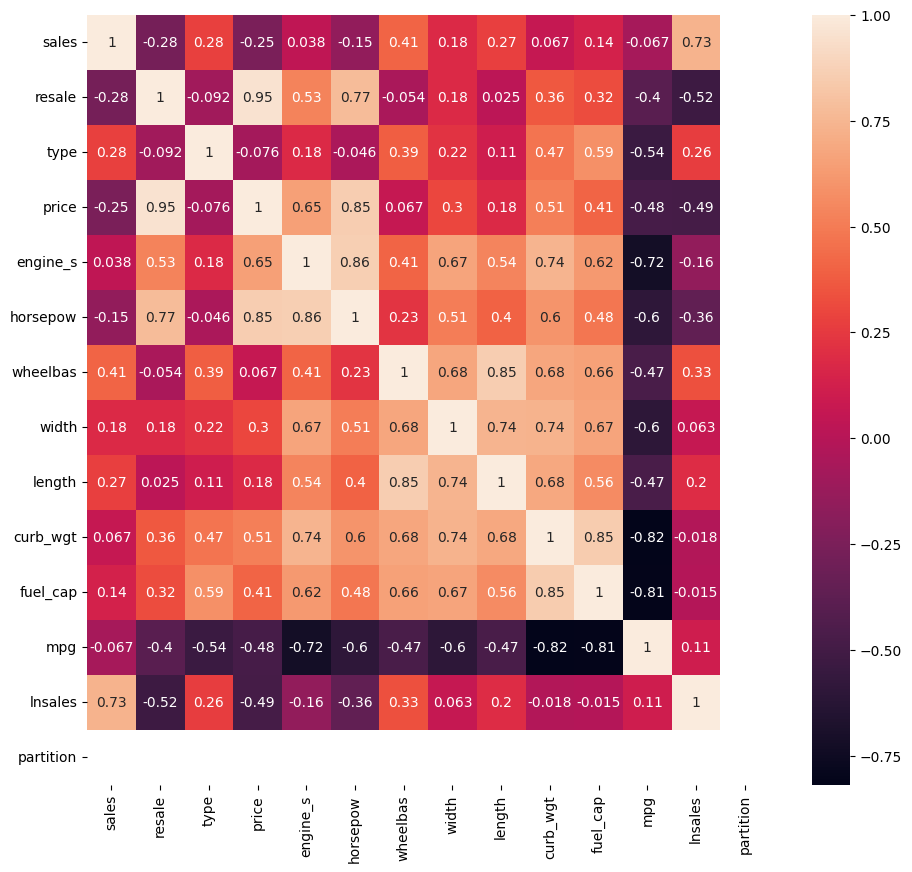

In [3]:
plt.figure(figsize=(11,10))
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [4]:
# function for calculating which product occur multiple times and how much time it occur
def duplicates(column_name):
    counts = df[column_name].value_counts()
    duplicates = counts[counts > 1]
    result = duplicates.reset_index()
    result.columns = [column_name, 'Count']
    print(result)

duplicates("manufact")
print()
duplicates("model")
print()
print("This means that model has no duplicate values, all are different so it's better to drop it")
print(df.columns)

         manufact  Count
0            Ford     10
1           Dodge      9
2       Chevrolet      8
3          Toyota      8
4      Mitsubishi      7
5         Mercury      6
6        Chrysler      5
7           Honda      5
8         Pontiac      5
9          Nissan      5
10     Volkswagen      5
11  Mercedes-Benz      4
12     Oldsmobile      4
13          Buick      4
14         Saturn      3
15        Porsche      3
16       Plymouth      3
17          Acura      3
18           Audi      3
19           Jeep      3
20        Hyundai      3
21       Cadillac      3
22          Lexus      3
23        Lincoln      2
24            BMW      2

  model  Count
0  Neon      2

This means that model has no duplicate values, all are different so it's better to drop it
Index(['manufact', 'model', 'sales', 'resale', 'type', 'price', 'engine_s',
       'horsepow', 'wheelbas', 'width', 'length', 'curb_wgt', 'fuel_cap',
       'mpg', 'lnsales', 'partition'],
      dtype='object')


In [5]:
df = df.drop(columns=['lnsales', 'partition','model','manufact'])
print(df.columns)

Index(['sales', 'resale', 'type', 'price', 'engine_s', 'horsepow', 'wheelbas',
       'width', 'length', 'curb_wgt', 'fuel_cap', 'mpg'],
      dtype='object')


In [6]:
print("All columns are")
ai=0
for i in df:
    print(ai,i)
    ai+=1

All columns are
0 sales
1 resale
2 type
3 price
4 engine_s
5 horsepow
6 wheelbas
7 width
8 length
9 curb_wgt
10 fuel_cap
11 mpg


In [10]:
tx = df[['sales','resale', 'type', 'engine_s', 'horsepow', 'wheelbas', 'width','length', 'curb_wgt', 'fuel_cap', 'mpg']]
print(tx.columns)
ty = df.iloc[:,3]
print(ty)
txain,txest,tyain,tyest = train_test_split(tx,ty,test_size=0.2)

Index(['sales', 'resale', 'type', 'engine_s', 'horsepow', 'wheelbas', 'width',
       'length', 'curb_wgt', 'fuel_cap', 'mpg'],
      dtype='object')
0      21.50
1      28.40
2      42.00
3      23.99
4      33.95
       ...  
112    14.90
113    16.70
114    21.20
115    19.99
116    17.50
Name: price, Length: 117, dtype: float64


In [11]:
# Linear Regression without scaling predicting price
tlr = LinearRegression()

tlr.fit(txain,tyain)

tpred = tlr.predict(txest)

print(r2_score(tyest,tpred))

0.9412302530401497


In [12]:
tscores = cross_val_score(tlr, tx, ty, cv=10, scoring="r2")

print('Actual cross-val results')
print(f"Scores for each fold: {tscores}")
print(f"Mean Accuracy: {tscores.mean():.2f}")
print(f"Standard Deviation: {tscores.std():.2f}")

Actual cross-val results
Scores for each fold: [0.86559595 0.97399036 0.90479839 0.65736622 0.80456497 0.88666201
 0.951845   0.89680832 0.98873147 0.95348851]
Mean Accuracy: 0.89
Standard Deviation: 0.09


In [13]:
print("All columns are")
ai=0
for i in df:
    print(ai,i)
    ai+=1

All columns are
0 sales
1 resale
2 type
3 price
4 engine_s
5 horsepow
6 wheelbas
7 width
8 length
9 curb_wgt
10 fuel_cap
11 mpg
